25.04.2025
moved the file from the plot logdata repo to the postprocess repo

24.04
i am looking at this data again, to see how i can reuse functions here to plot my new reflectance data and see where the differences are 

16.04:
this data is valuable in the sense that it can visualize everything, but will not currently be used further to find distinct features as we first thought. will now move forward with CNN 


14.04
pure classification pipeline -> follow notion: https://www.notion.so/erikliiu/pipeline-of-postprocessing-1b2904190efd80ec8217e7a061b4097e

transects (.h5):        desc:                                                                                               quality [1-10]      usage [1-10]    num. of clips
221                     pipe, bad shadowing, no bombs. treestem                                                             2                   3               5
520-from1               too short                                                                                           9                   1?              1
520-from3         *     first transect: use for classify dark spots, leafes, square rock, fish, ~3 bombs                    7                   6               3
057               *     generally even illu., 10+ bombs, good for classify bombs (but not dark spots)                       8                   9               5
639               *     last transect: useable, 10+ bombs, alt. oscillating (hard to classify?)                             7                   4               5
028               *    first transect: good separability (dark vs. sed.), no bombs, many dark spots, even illu.            8                   8               5
135                     even illu, few dark spots (not very distinct), no bombs                                             10                  2               2

ref. plate:
504                     looks useable, but short
648                     also usable, longer

summary: use 057 and 639 as they have most bombs 

In [1]:
import os
import re
import pandas as pd
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

folder_path = r"E:\mjosa\29\ROIs\statistics_rad"
header_printed = False


def find_data_start(filepath):
    """
    Finds the starting line of the numeric data in a text file.
    """
    with open(filepath, "r") as f:
        for i, line in enumerate(f):
            if re.match(r"^\s*[-+]?\d", line):
                return i
    return 0


def plot_roi(roi_dict, keys):
    """
    Plots the ROI data for one or more keys from the roi_dict.

    Parameters:
        roi_dict (dict): Dictionary with ROI DataFrames.
        keys (str or list): One or more keys to plot.
    """
    if isinstance(keys, str):
        keys = [keys]  # Wrap single string into a list

    plt.figure(figsize=(8, 5))

    for key in keys:
        df = roi_dict[key]
        plt.plot(df["Wavelength"], df["Mean"], linestyle="-", label=str(key))

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Mean Value")
    # plt.title("ROI: Spectral Mean")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_different_spectra(roi_dict, key1, key2):
    """
    Plots the difference between the "Mean" spectra of two ROIs and annotates
    the maximum difference value with its corresponding wavelength.

    Parameters:
        roi_dict (dict): Dictionary with ROI data as DataFrames.
        key1 (str): Key for the first ROI.
        key2 (str): Key for the second ROI.
    """
    df1 = roi_dict[key1]
    df2 = roi_dict[key2]

    # Ensure the data have the same wavelength scale
    if not df1["Wavelength"].equals(df2["Wavelength"]):
        common = pd.merge(df1, df2, on="Wavelength", suffixes=("_1", "_2"))
        wavelengths = common["Wavelength"]
        diff = common["Mean_1"] - common["Mean_2"]
    else:
        wavelengths = df1["Wavelength"]
        diff = df1["Mean"] - df2["Mean"]

    # Locate the maximum difference value
    idx = diff.idxmax()
    max_value = diff.loc[idx]
    max_wavelength = wavelengths.loc[idx]

    plt.figure(figsize=(8, 5))
    # Plot the difference spectrum without markers
    plt.plot(wavelengths, diff, linestyle="-")
    # Draw a vertical dashed line at the maximum difference wavelength
    plt.axvline(max_wavelength, color="green", linestyle="--", alpha=0.7)

    # Annotate the maximum difference
    plt.annotate(
        f"Max radiance: {max_value:.4f} at {max_wavelength:.1f} nm",
        xy=(max_wavelength, max_value),
        xytext=(max_wavelength + 25, max_value),
        fontsize=10,
        backgroundcolor="w",
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Difference in Radiance")
    plt.title(f"{key1} - {key2}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def normalize_roi_data(roi_dict):
    """
    Returns a new dictionary with the same keys as roi_dict,
    but with the 'Mean' values normalized by their max value.
    """
    normalized_dict = {}
    for key, df in roi_dict.items():
        df_copy = df.copy()
        max_val = df_copy["Mean"].max()
        if max_val != 0:
            df_copy["Mean"] = df_copy["Mean"] / max_val
        normalized_dict[key] = df_copy
    return normalized_dict


def min_max_normalize_mean(roi_dict):
    """
    Returns a new dictionary where each ROI's 'Mean' is min-max normalized:
        normalized = (Mean - Mean.min()) / (Mean.max() - Mean.min())
    This reflects the shape of the mean spectrum only.
    """
    normalized_dict = {}
    for key, df in roi_dict.items():
        df_copy = df.copy()
        min_val = df_copy["Mean"].min()
        max_val = df_copy["Mean"].max()

        # Avoid division by zero
        range_val = max_val - min_val if max_val != min_val else 1e-8

        df_copy["Mean"] = (df_copy["Mean"] - min_val) / range_val
        normalized_dict[key] = df_copy

    return normalized_dict


def flat_field_correct_roi_data(
    roi_dict, reference_key, start_wavelength, end_wavelength
):
    """
    Applies flat field correction to a dictionary of ROI DataFrames within a given wavelength range.
    Each ROI's 'Mean' spectrum is divided by the reference ROI's 'Mean' spectrum.
    This yields a relative reflectance for each ROI.

    Parameters:
        roi_dict (dict): Dictionary of ROI DataFrames, each with 'Wavelength' and 'Mean' columns.
        reference_key (str): Key of the flat-field ROI to use as reference (e.g., 'darkspots_no_bombs').
        start_wavelength (float): Starting wavelength to include.
        end_wavelength (float): Ending wavelength to include.

    Returns:
        dict: New dictionary with the corrected and filtered DataFrames.
    """
    corrected_dict = {}

    # Filter reference DataFrame to desired wavelength range
    ref_df = roi_dict[reference_key]
    ref_filtered = ref_df[
        (ref_df["Wavelength"] >= start_wavelength)
        & (ref_df["Wavelength"] <= end_wavelength)
    ]
    reference_spectrum = ref_filtered["Mean"].values

    # Prevent division by zero
    reference_spectrum = np.where(reference_spectrum == 0, 1e-8, reference_spectrum)

    for key, df in roi_dict.items():
        # Filter to same wavelength range
        df_filtered = df[
            (df["Wavelength"] >= start_wavelength)
            & (df["Wavelength"] <= end_wavelength)
        ].copy()

        if len(df_filtered["Mean"]) != len(reference_spectrum):
            raise ValueError(f"Mismatch in band length for key '{key}' after filtering")

        df_filtered["Mean"] = df_filtered["Mean"].values / reference_spectrum
        corrected_dict[key] = df_filtered

    return corrected_dict


def load_data(folder_path, wavelength_min=None, wavelength_max=None):
    """
    Loads all ROI .txt files from the given folder into a dictionary of DataFrames,
    optionally filtering by wavelength range.

    Parameters:
        folder_path (str): Path to the folder containing .txt ROI files.
        wavelength_min (float): Optional minimum wavelength to keep.
        wavelength_max (float): Optional maximum wavelength to keep.

    Returns:
        dict: Dictionary where keys are filenames (without .txt) and values are filtered DataFrames.
    """
    roi_data = {}
    header_printed = False

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            skip = find_data_start(file_path)
            df = pd.read_csv(file_path, sep=r"\s+", header=None, skiprows=skip)
            df.columns = [
                "Wavelength",
                "Min",
                "Mean-StdDev",
                "Mean",
                "Mean+StdDev",
                "Max",
            ]

            # Filter wavelengths if range is specified
            if wavelength_min is not None:
                df = df[df["Wavelength"] >= wavelength_min]
            if wavelength_max is not None:
                df = df[df["Wavelength"] <= wavelength_max]

            if not header_printed:
                print("Columns:", df.columns.tolist())
                header_printed = True

            key = os.path.splitext(filename)[0]
            roi_data[key] = df

    print("Loaded ROI files:", list(roi_data.keys()))
    return roi_data

In [2]:
roi_data = load_data(folder_path)


print("\n")


print(roi_data["perfect_vertical_bomb"])

Columns: ['Wavelength', 'Min', 'Mean-StdDev', 'Mean', 'Mean+StdDev', 'Max']
Loaded ROI files: ['sediment_darkspots_no_bombs', 'darkspots_no_bombs', 'maybe_corrosion', 'dark_trippel', 'dark_vertical', 'dark_double', 'sediment_double_bombs', 'double_large_bombs', 'tripple_small_bombs', 'sediment_tripple_bombs', 'sediment_perfect_vertical_bomb', 'perfect_vertical_bomb', 'reflectance_plate']


     Wavelength  Min  Mean-StdDev      Mean  Mean+StdDev       Max
0       380.913  0.0     0.000927  0.003685     0.006444  0.012680
1       382.598  0.0    -0.000110  0.002974     0.006058  0.014016
2       384.283  0.0     0.000360  0.004791     0.009222  0.019994
3       385.969  0.0     0.000046  0.004865     0.009683  0.020088
4       387.656  0.0     0.001037  0.005126     0.009215  0.020119
..          ...  ...          ...       ...          ...       ...
205     741.285  0.0     0.001161  0.005397     0.009632  0.020891
206     743.117  0.0     0.000745  0.003671     0.006598  0.013170
207 

In [3]:
# Define sediment-related keys
sediment_keys = [
    "sediment_darkspots_no_bombs",
    "sediment_double_bombs",
    "sediment_tripple_bombs",
    "sediment_perfect_vertical_bomb",
]

# Define dark-related keys
dark_keys = ["darkspots_no_bombs", "dark_trippel", "dark_vertical", "dark_double"]

# Define bomb-related keys (assuming we include only those with bombs)
bomb_keys = [
    "perfect_vertical_bomb",
    "double_large_bombs",
    "tripple_small_bombs",
]

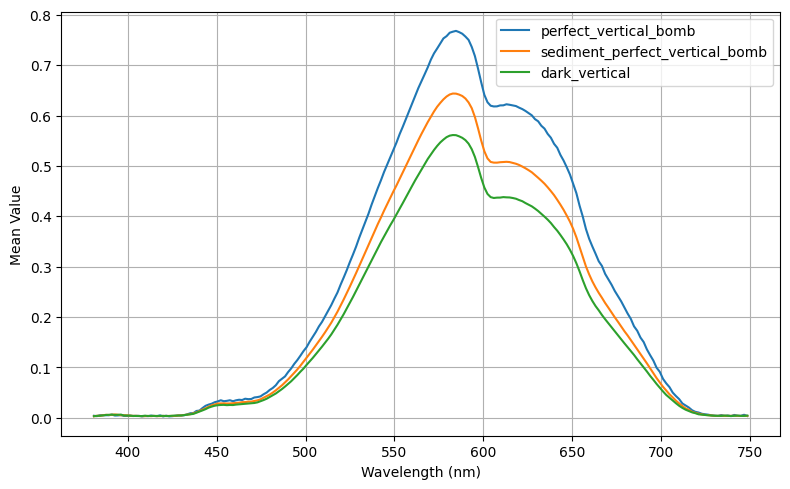

In [4]:
plot_roi(
    roi_data,
    ["perfect_vertical_bomb", "sediment_perfect_vertical_bomb", "dark_vertical"],
)

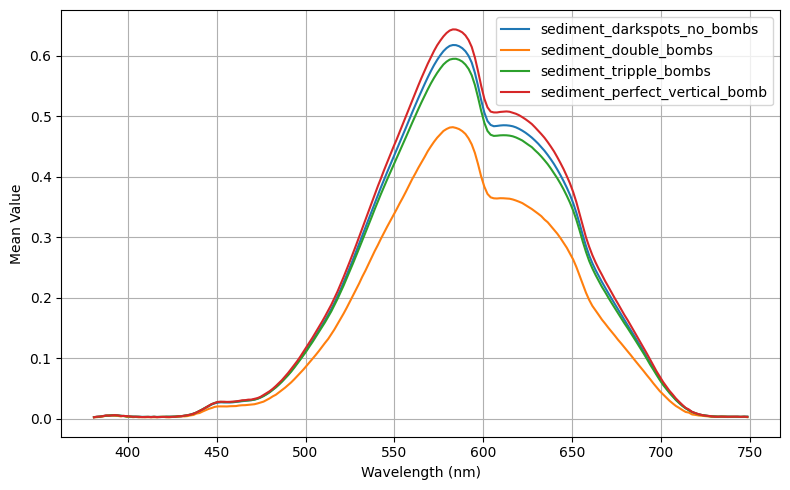

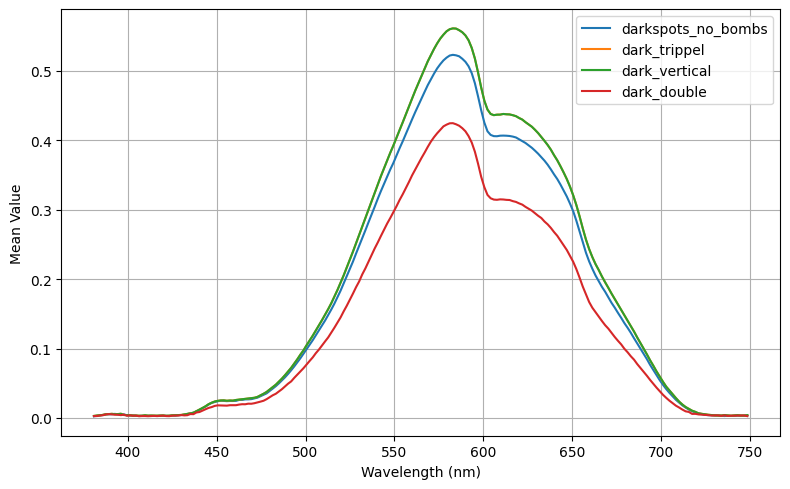

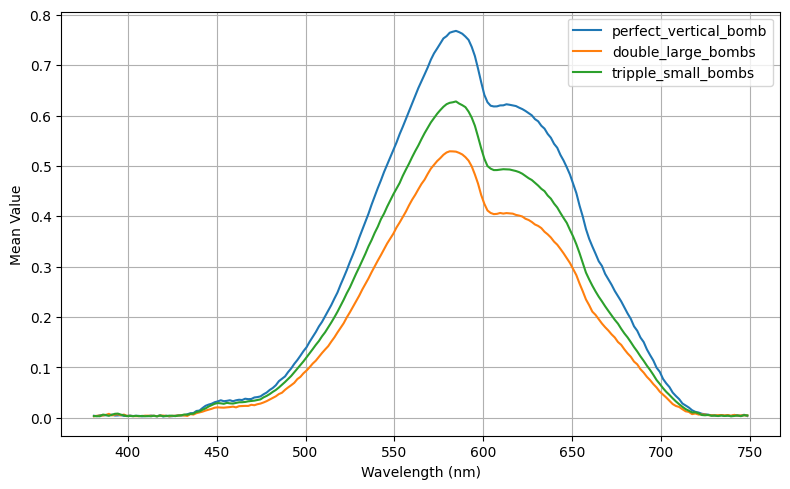

In [5]:
# Plot all sediments together
plot_roi(roi_data, sediment_keys)

# Plot all dark things together
plot_roi(roi_data, dark_keys)

# Plot all bombs together
plot_roi(roi_data, bomb_keys)

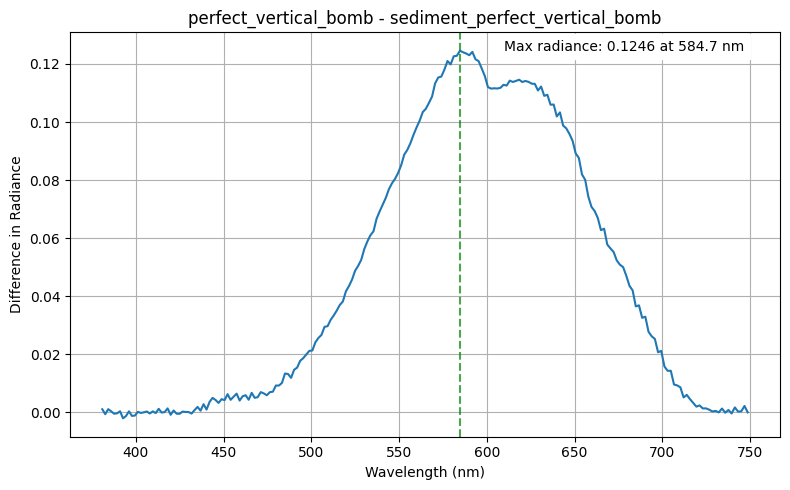

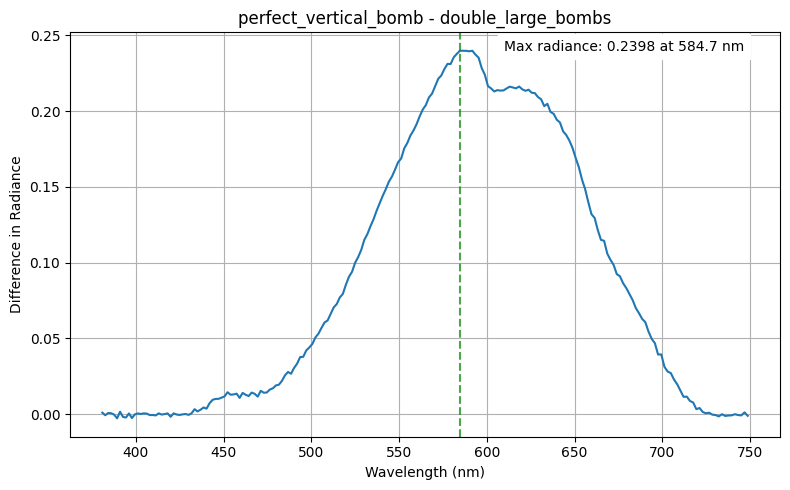

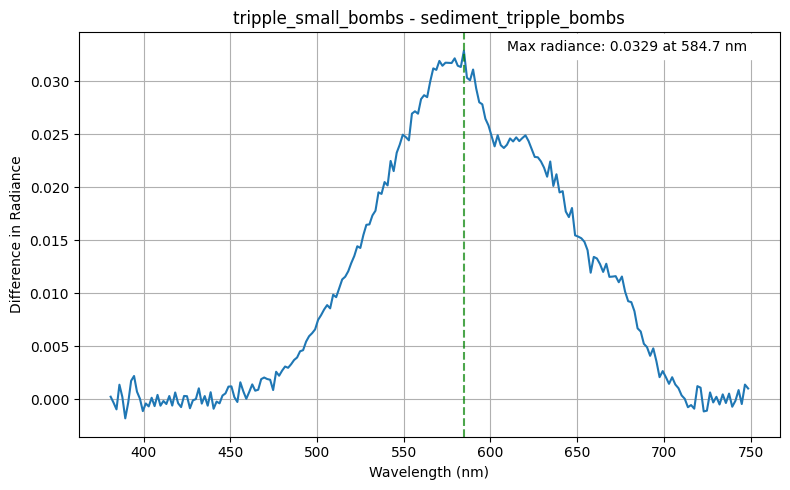

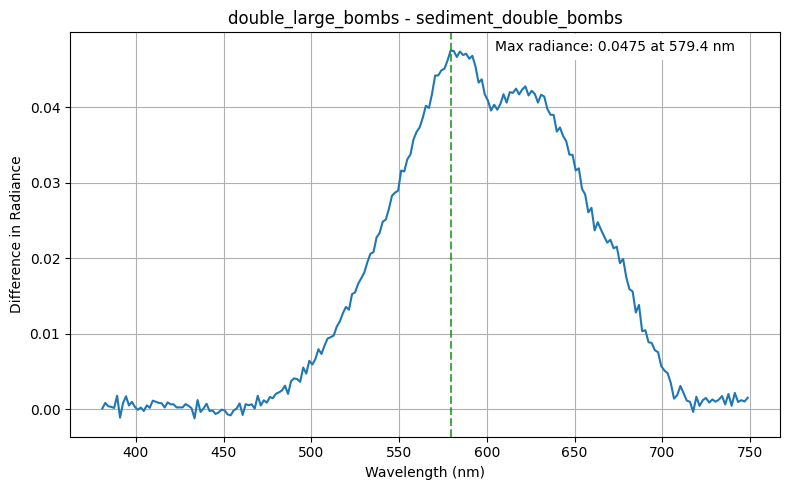

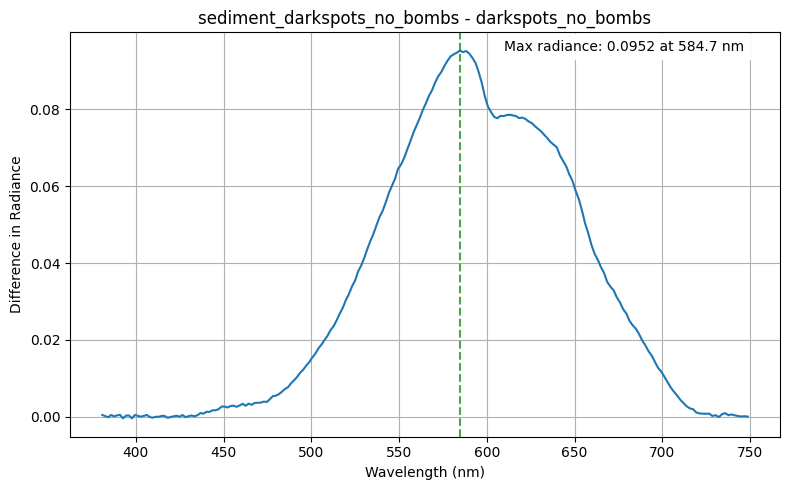

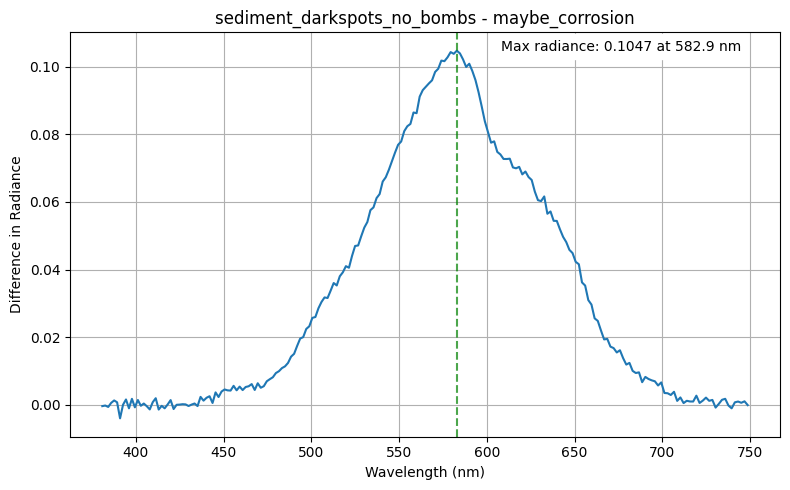

In [6]:
plot_different_spectra(
    roi_data, "perfect_vertical_bomb", "sediment_perfect_vertical_bomb"
)
plot_different_spectra(roi_data, "perfect_vertical_bomb", "double_large_bombs")
plot_different_spectra(roi_data, "tripple_small_bombs", "sediment_tripple_bombs")
plot_different_spectra(roi_data, "double_large_bombs", "sediment_double_bombs")
plot_different_spectra(roi_data, "sediment_darkspots_no_bombs", "darkspots_no_bombs")
plot_different_spectra(roi_data, "sediment_darkspots_no_bombs", "maybe_corrosion")

above i tried to find differences, but see that many are similar, i suspect only difference is intensity. thus i will try to normalize to see if theres any difference in the shape and not intensity

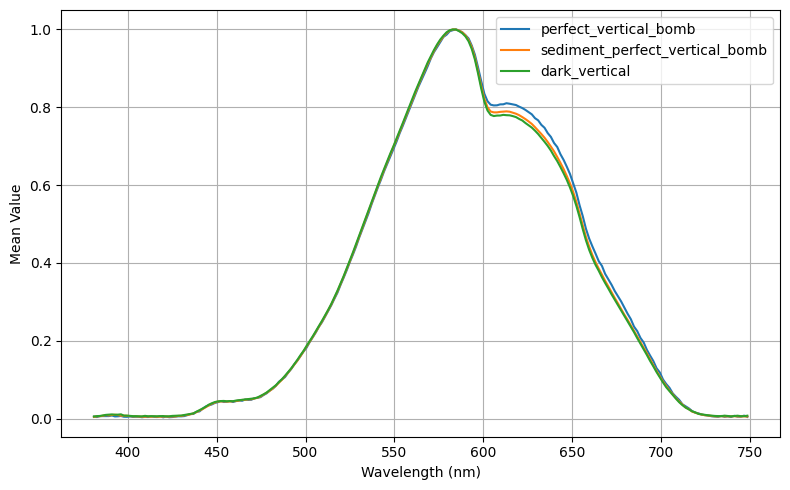

In [7]:
# Step 1: Normalize with max normaliaztion
normalized_data = normalize_roi_data(roi_data)

# Step 2: Plot normalized curves
plot_roi(
    normalized_data,
    ["perfect_vertical_bomb", "sediment_perfect_vertical_bomb", "dark_vertical"],
)

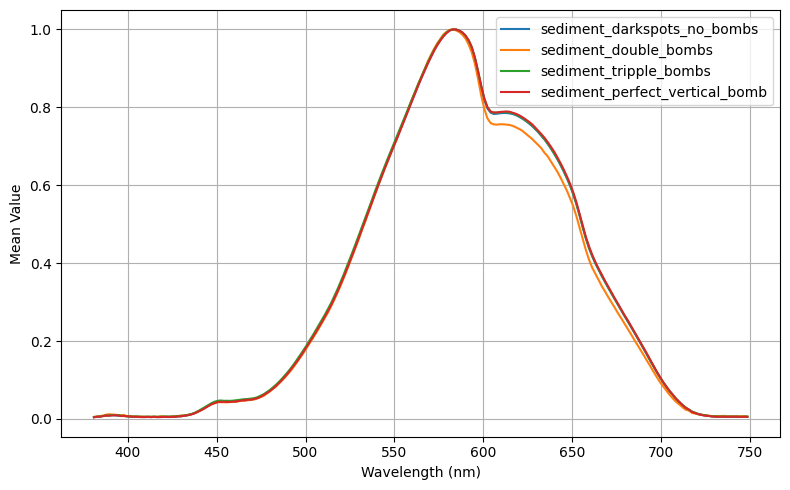

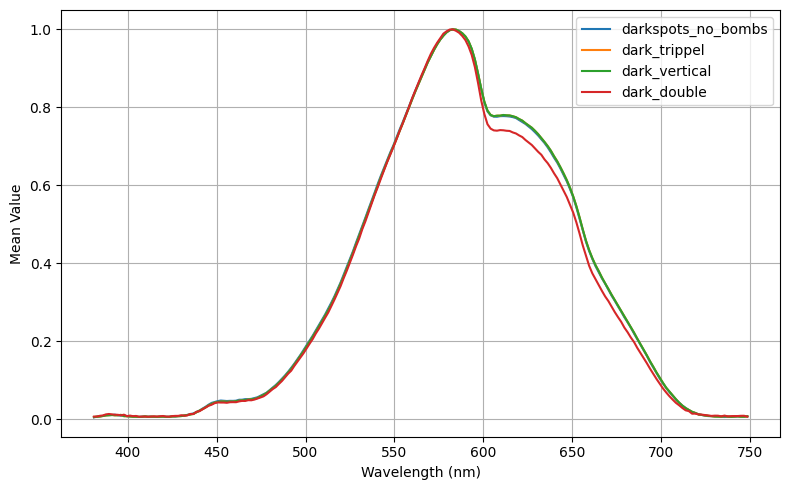

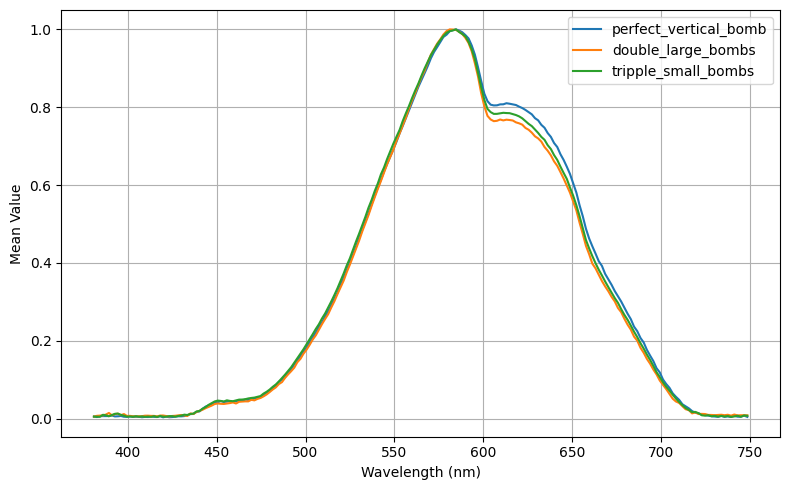

In [8]:
# Plot all normalized sediments together
plot_roi(normalized_data, sediment_keys)

# Plot all normalized dark things together
plot_roi(normalized_data, dark_keys)

# Plot all normalized bombs together
plot_roi(normalized_data, bomb_keys)

theres also another way to nornmalzie, test to see if i see any results

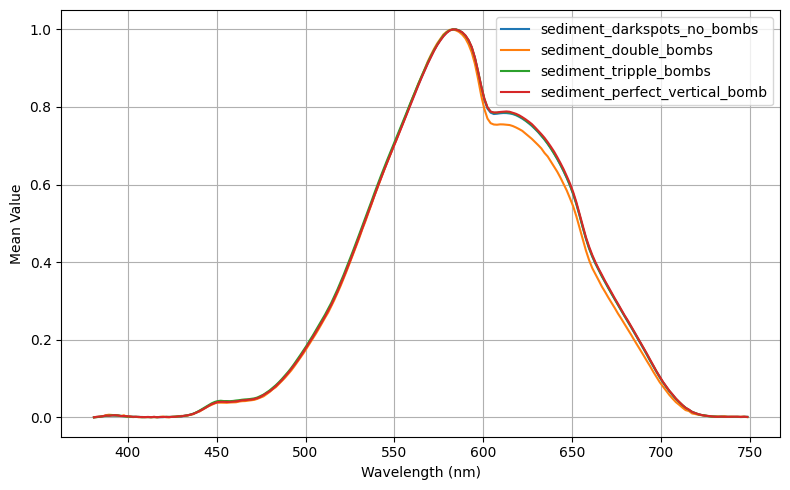

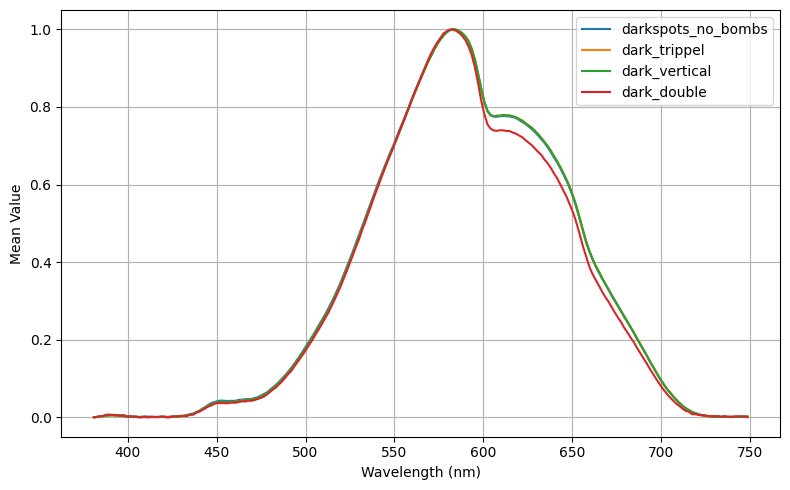

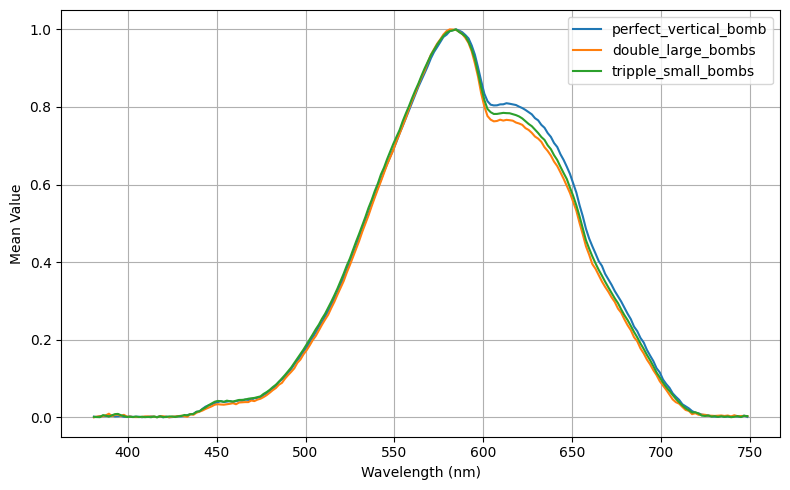

In [9]:
# Apply correct min-max normalization to 'Mean' column
normalized_minmax = min_max_normalize_mean(roi_data)

# Then plot groups as usual
plot_roi(normalized_minmax, sediment_keys)
plot_roi(normalized_minmax, dark_keys)
plot_roi(normalized_minmax, bomb_keys)

see that the two nornmalization methods are identical, so theres no issue with the normnalization, i will now try to convert to reflecatnce instead

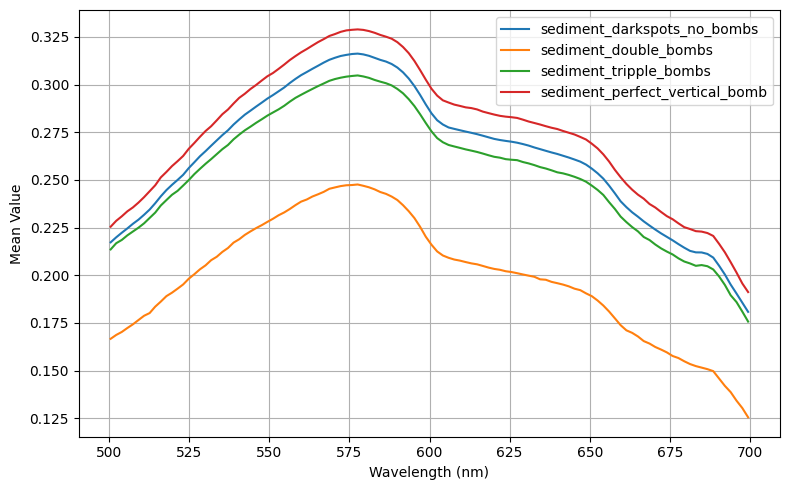

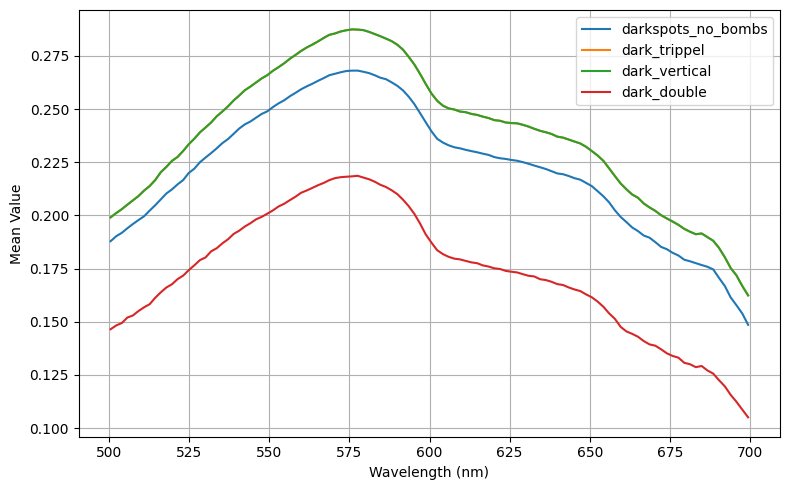

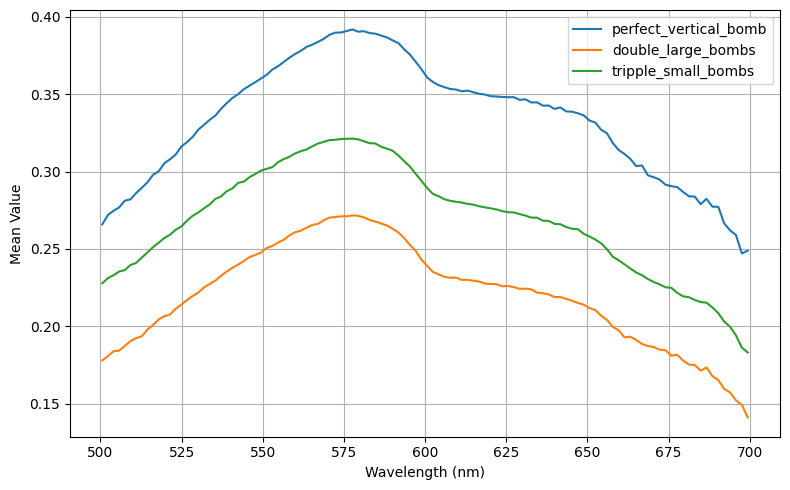

In [10]:
# Perform flat field correction using "reflectance_platet" as your reference ROI
corrected_data = flat_field_correct_roi_data(
    roi_data,
    reference_key="reflectance_plate",
    start_wavelength=500,
    end_wavelength=700,
)

plot_roi(corrected_data, sediment_keys)
plot_roi(corrected_data, dark_keys)
plot_roi(corrected_data, bomb_keys)

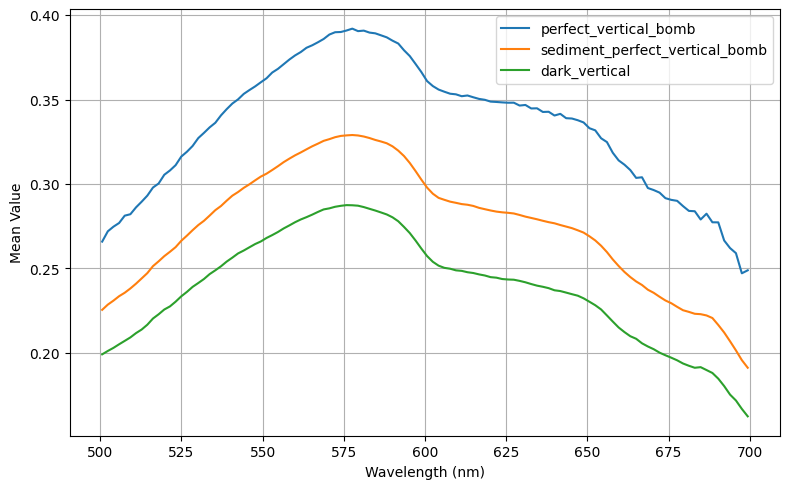

In [11]:
plot_roi(
    corrected_data,
    ["perfect_vertical_bomb", "sediment_perfect_vertical_bomb", "dark_vertical"],
)

when i comapre this to envi it looks shit -> the values dont look correct. so i use the flat field correction found in toolbox. i will now compare the difference spectra in reflectance for the vertical bomb

Columns: ['Wavelength', 'Min', 'Mean-StdDev', 'Mean', 'Mean+StdDev', 'Max']
Loaded ROI files: ['sed_vertical', 'vertical', 'dark_vertical', 'tripple', 'sed_tripple', 'dark_tripple', 'sed_double', 'double', 'dark_double', 'darkspots', 'sed_darkspots']


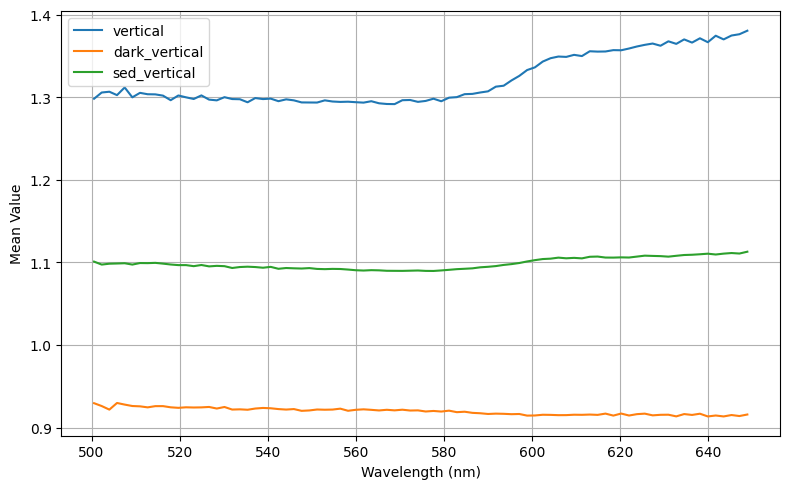

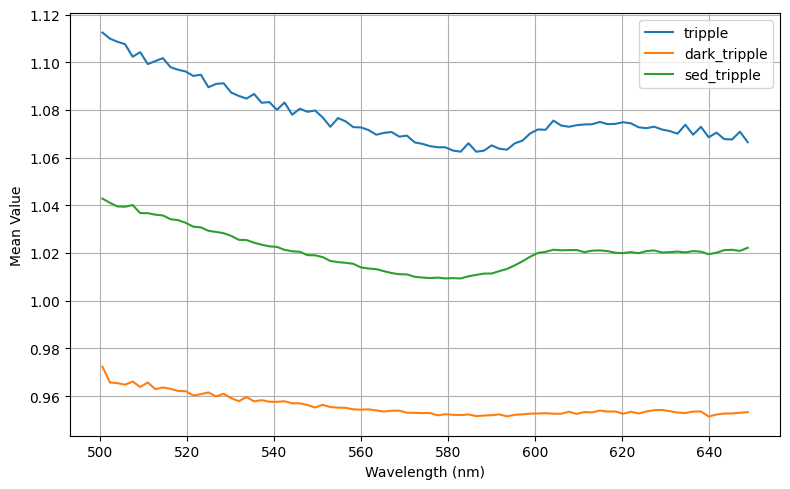

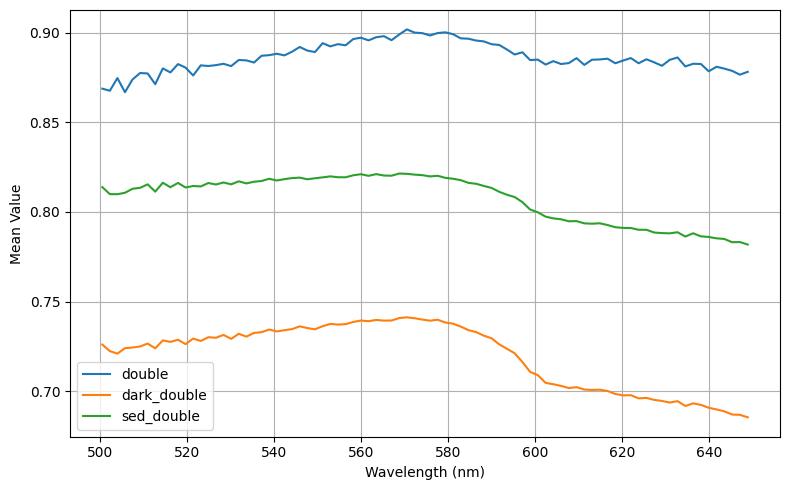

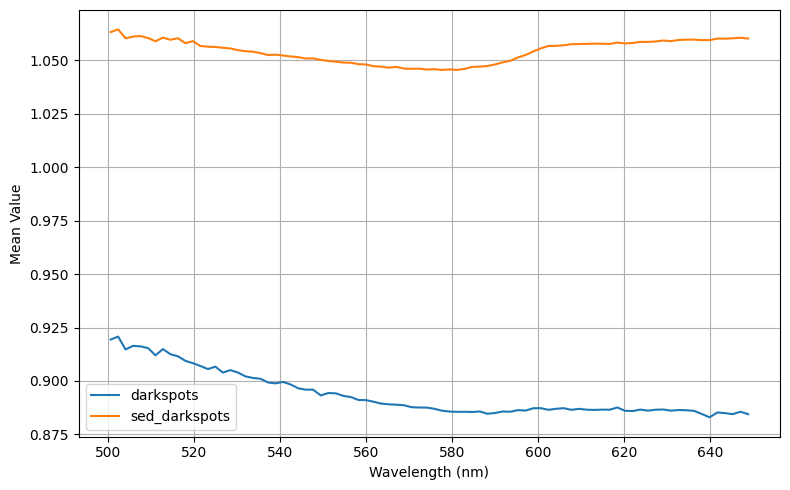

In [12]:
refl_folder = r"E:\mjosa\29\ROIs\statistics_refl"
refl_data = load_data(refl_folder, wavelength_min=500, wavelength_max=650)
# refl_data = load_data(refl_folder, wavelength_min=400, wavelength_max=750)

plot_roi(refl_data, ["vertical", "dark_vertical", "sed_vertical"])
plot_roi(refl_data, ["tripple", "dark_tripple", "sed_tripple"])
plot_roi(refl_data, ["double", "dark_double", "sed_double"])
plot_roi(refl_data, ["darkspots", "sed_darkspots"])

see that there are some differences, try to enhance them by plotting difference spectra

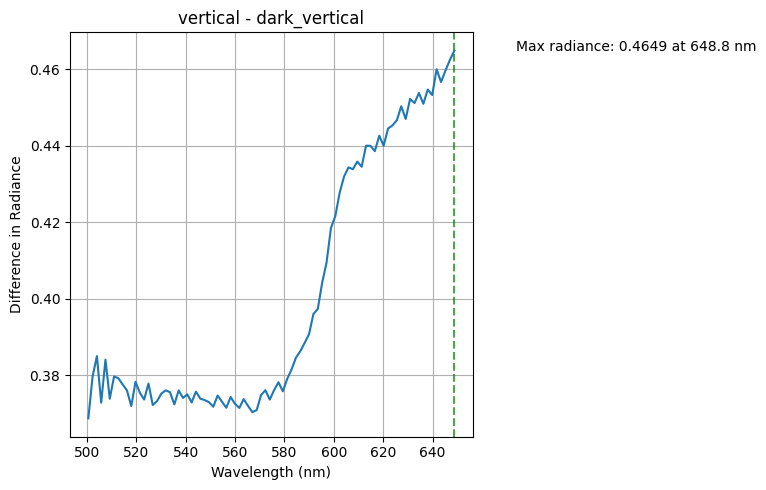

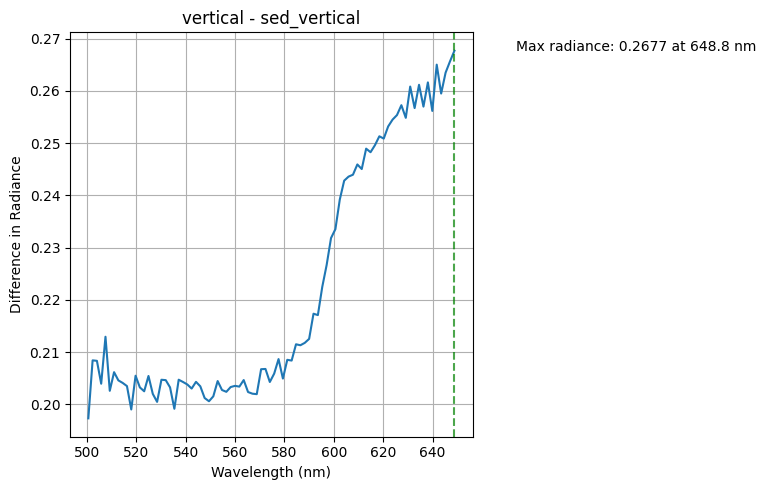

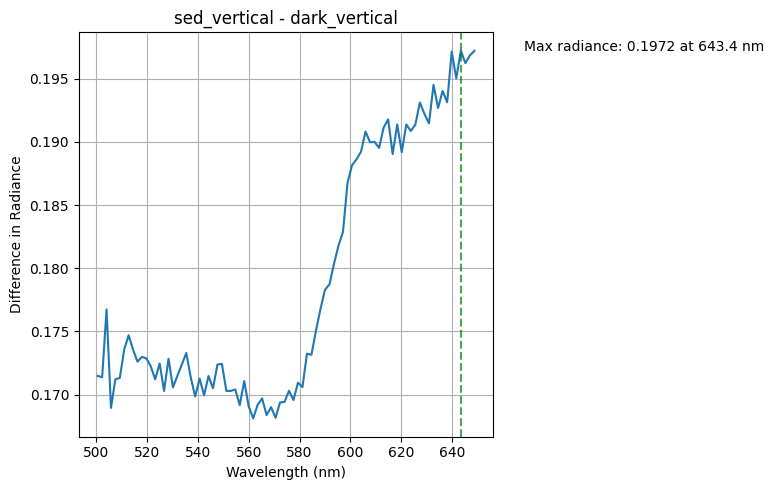

In [13]:
# --------- VERTICAL COMPARISONS ---------
plot_different_spectra(refl_data, "vertical", "dark_vertical")
plot_different_spectra(refl_data, "vertical", "sed_vertical")
plot_different_spectra(refl_data, "sed_vertical", "dark_vertical")

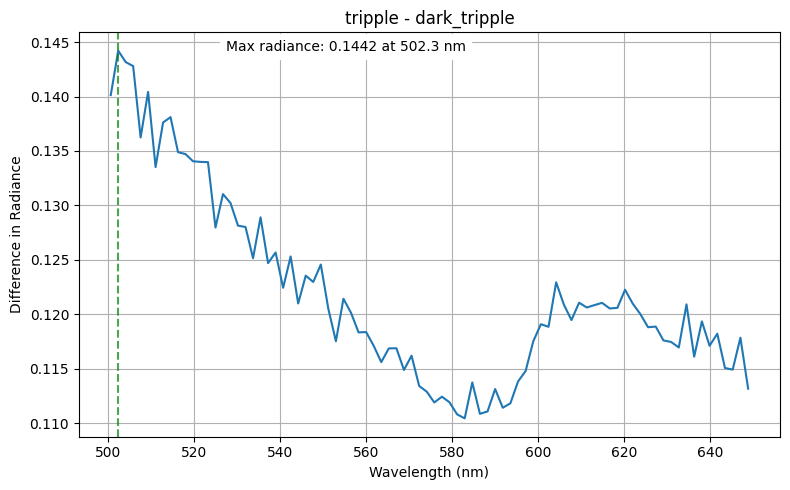

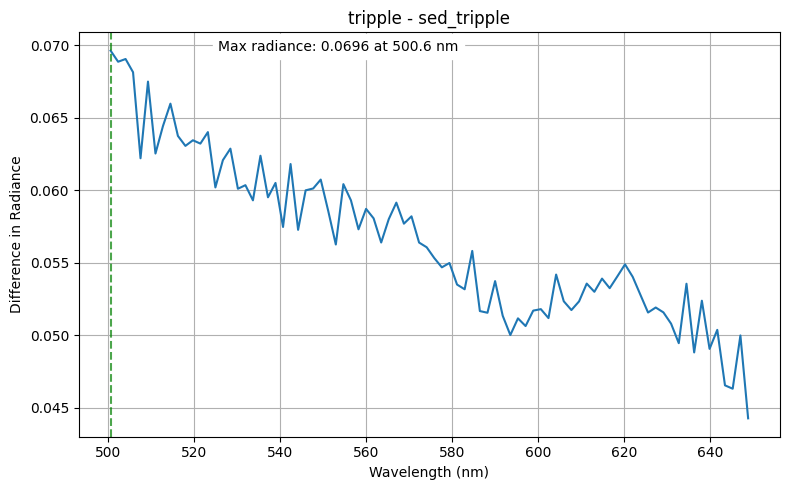

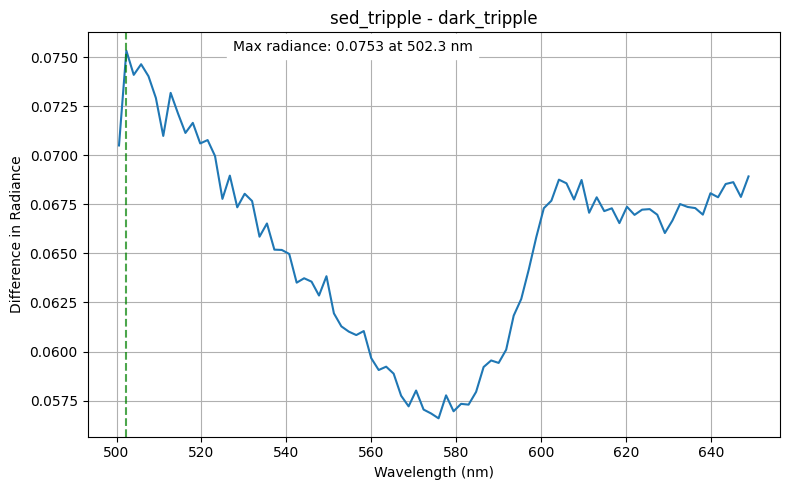

In [14]:
# --------- TRIPPLE COMPARISONS ---------
plot_different_spectra(refl_data, "tripple", "dark_tripple")
plot_different_spectra(refl_data, "tripple", "sed_tripple")
plot_different_spectra(refl_data, "sed_tripple", "dark_tripple")

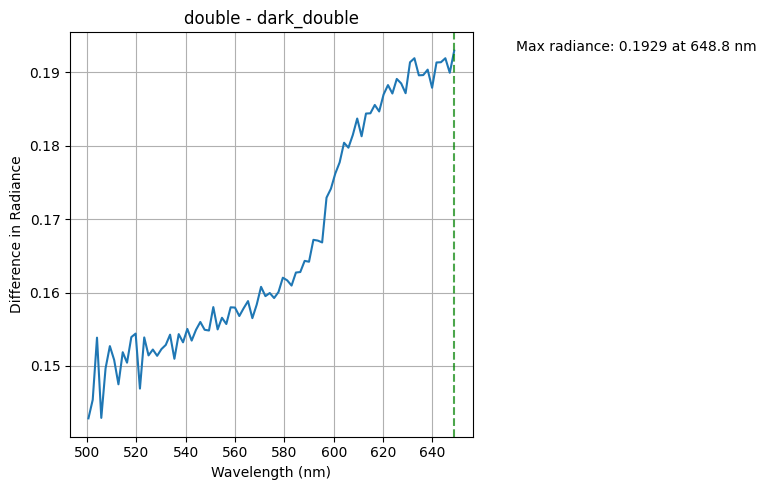

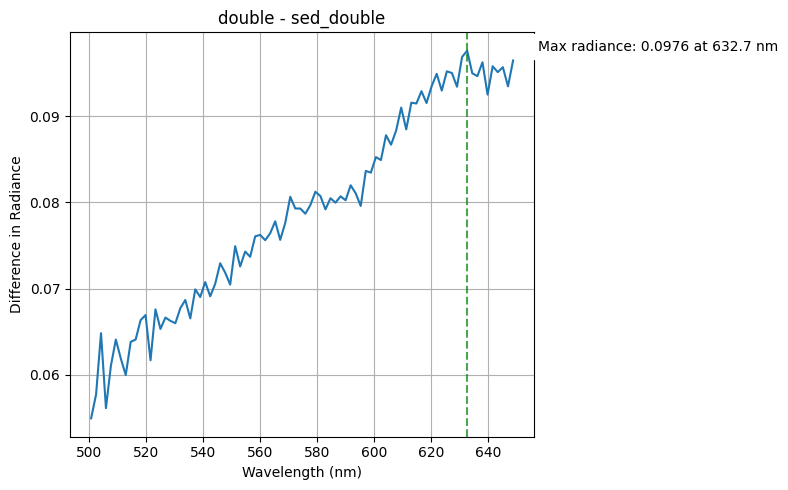

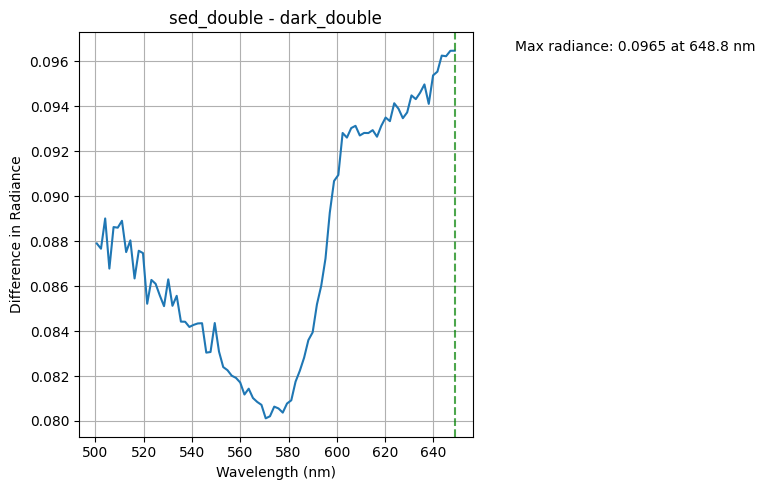

In [15]:
# --------- DOUBLE COMPARISONS ---------
plot_different_spectra(refl_data, "double", "dark_double")
plot_different_spectra(refl_data, "double", "sed_double")
plot_different_spectra(refl_data, "sed_double", "dark_double")

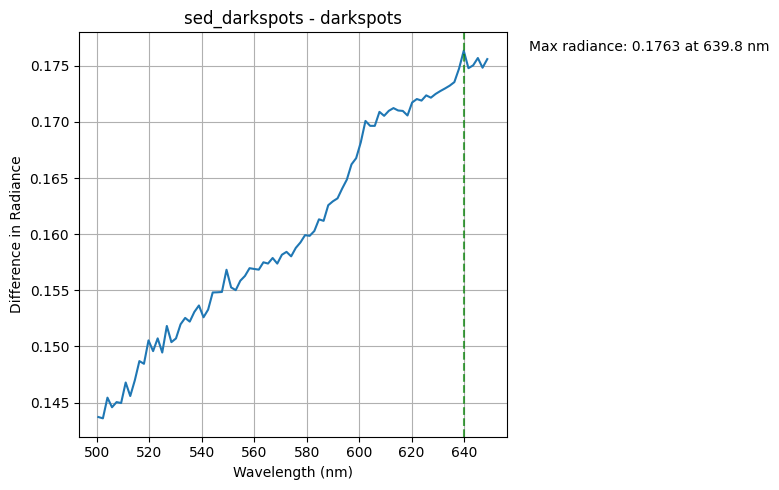

In [16]:
# --------- DARKSPOTS COMPARISON ---------
plot_different_spectra(refl_data, "sed_darkspots", "darkspots")

start here, understand what i am looking for
i guess i need to compare it to something, maybe i can use sediment vs sediemtn as reference? lets see how that looks

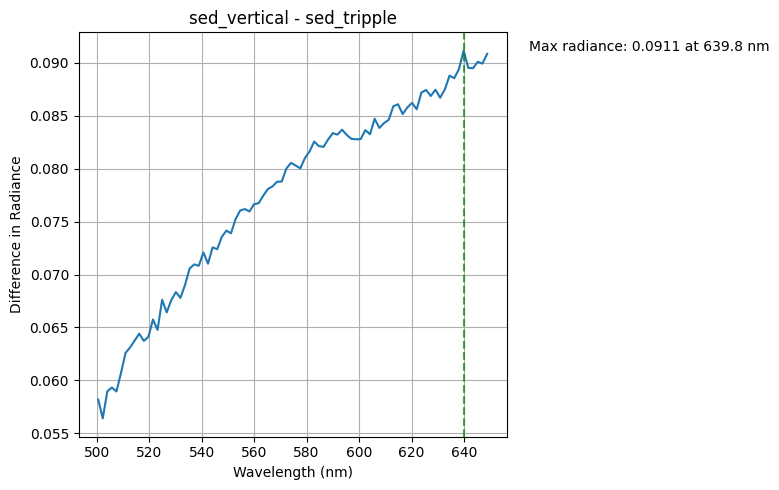

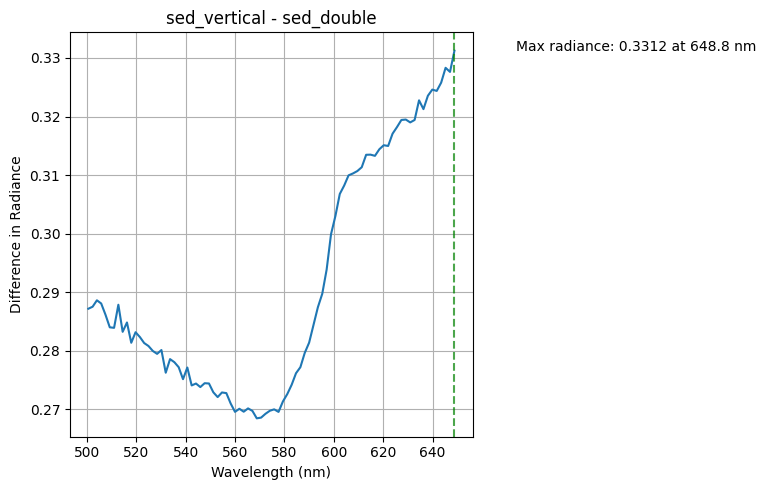

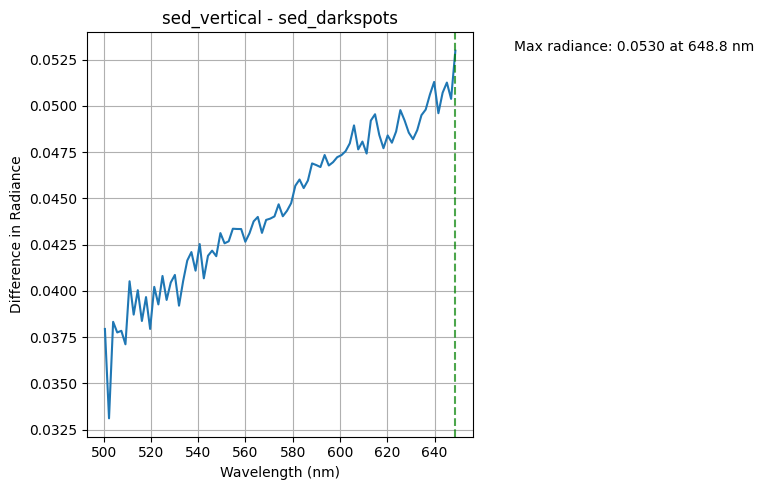

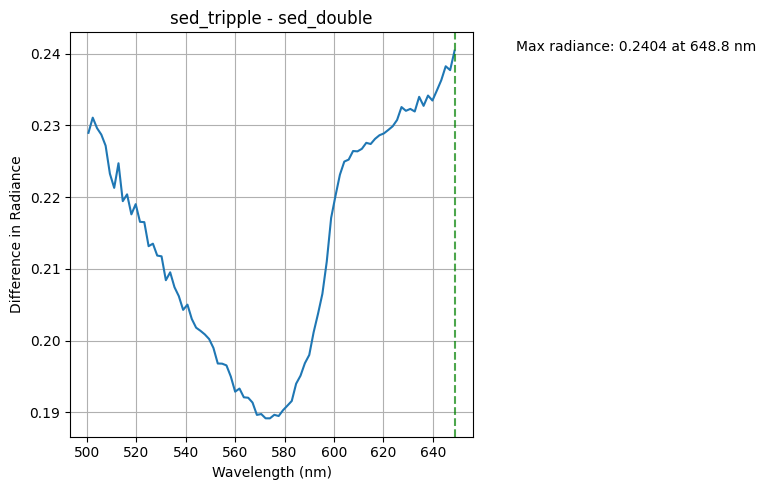

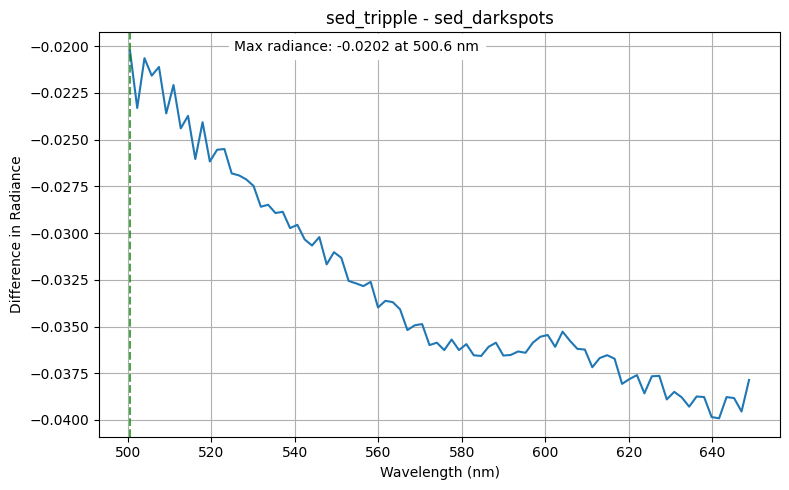

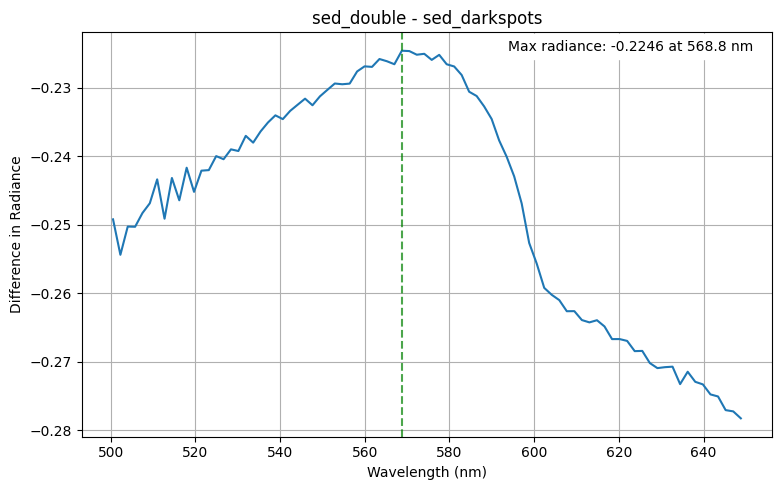

In [17]:
# --------- SEDIMENT COMPARISONS ---------
plot_different_spectra(refl_data, "sed_vertical", "sed_tripple")
plot_different_spectra(refl_data, "sed_vertical", "sed_double")
plot_different_spectra(refl_data, "sed_vertical", "sed_darkspots")

plot_different_spectra(refl_data, "sed_tripple", "sed_double")
plot_different_spectra(refl_data, "sed_tripple", "sed_darkspots")

plot_different_spectra(refl_data, "sed_double", "sed_darkspots")

summary: many plots, idk what i am looking for tbh

will try to create band ratios -> select one wvl we know theres a big difference vs. one with small difference. to do this we need to plot all the refl. together and see if theres any that stands out great 

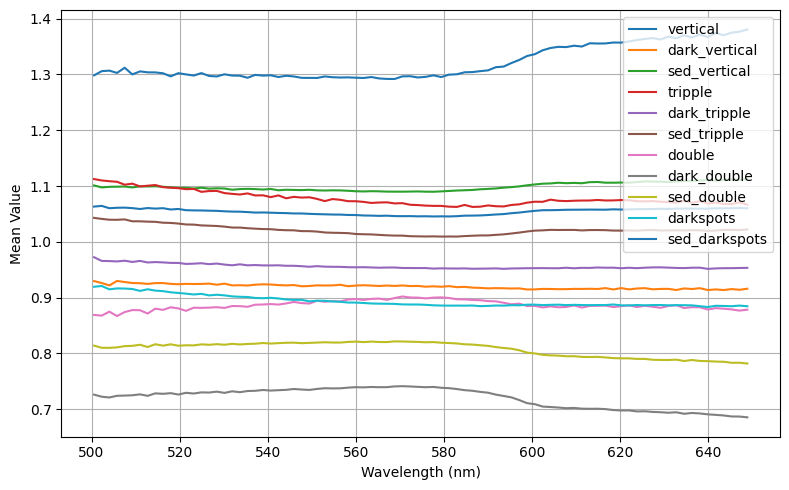

In [18]:
all_keys = [
    "vertical",
    "dark_vertical",
    "sed_vertical",
    "tripple",
    "dark_tripple",
    "sed_tripple",
    "double",
    "dark_double",
    "sed_double",
    "darkspots",
    "sed_darkspots",
]

# Plot them all together
plot_roi(refl_data, all_keys)

this dont tell us that much, tbh since we want to see if bomb can be discriminated based on the sediment close to it, so the plots above:

plot_roi(refl_data, ["vertical", "dark_vertical", "sed_vertical"])
plot_roi(refl_data, ["tripple", "dark_tripple", "sed_tripple"])
plot_roi(refl_data, ["double", "dark_double", "sed_double"])
plot_roi(refl_data, ["darkspots", "sed_darkspots"])

are better doing this, but since its different intensity, maybe we can see if we can normalize it? 

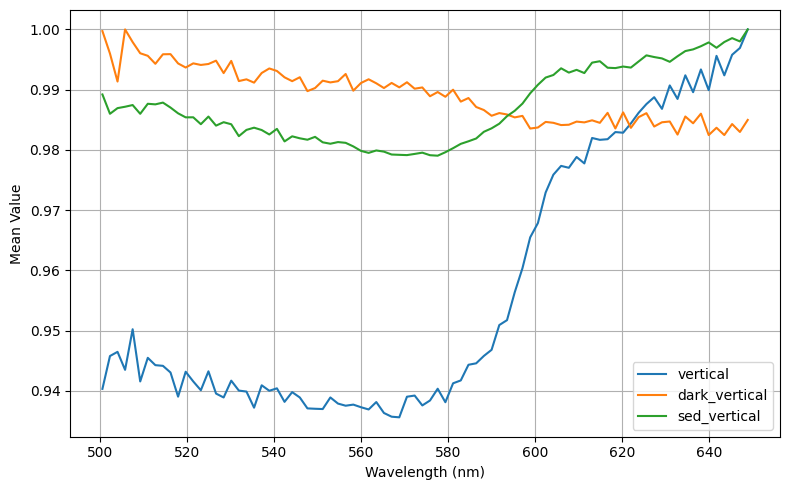

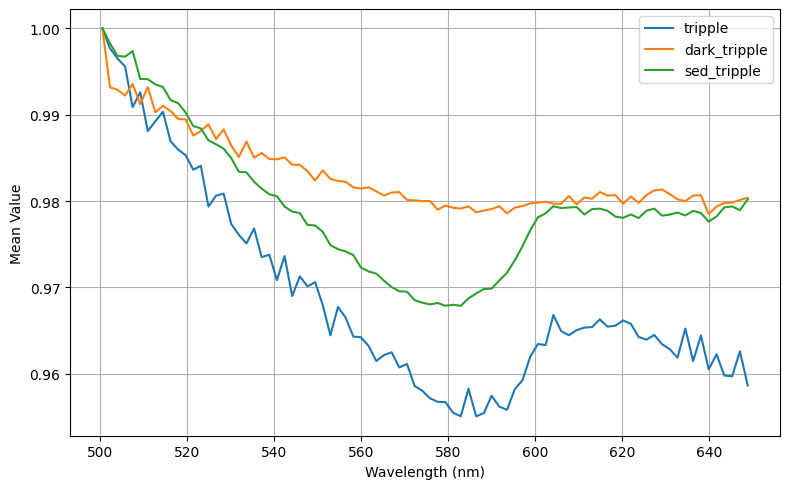

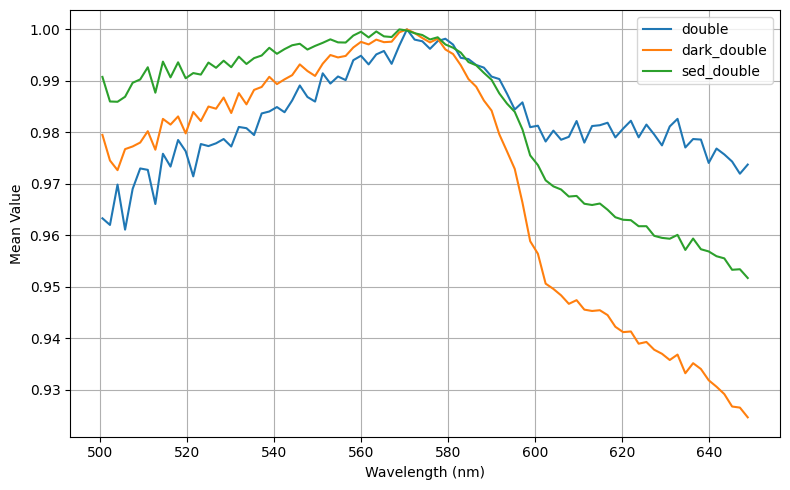

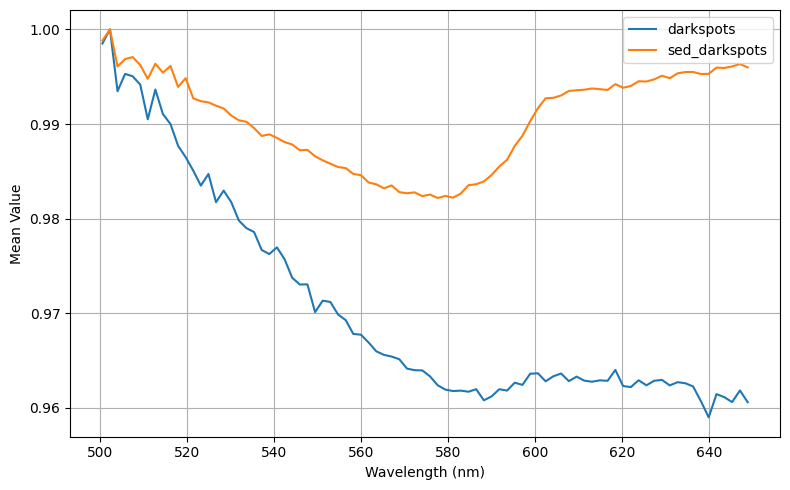

In [19]:
# Step 1: Normalize with max normaliaztion
normalized_refl_data = normalize_roi_data(refl_data)


plot_roi(normalized_refl_data, ["vertical", "dark_vertical", "sed_vertical"])
plot_roi(normalized_refl_data, ["tripple", "dark_tripple", "sed_tripple"])
plot_roi(normalized_refl_data, ["double", "dark_double", "sed_double"])
plot_roi(normalized_refl_data, ["darkspots", "sed_darkspots"])

looks like it might be large differences here that i can use 

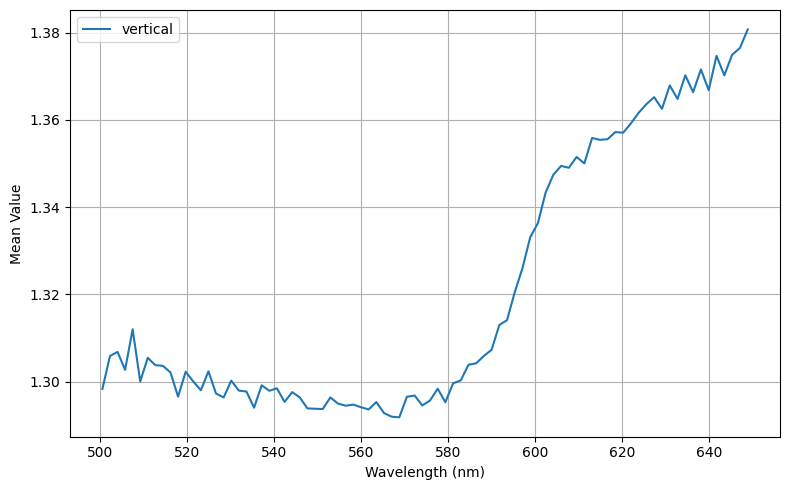

In [20]:
plot_roi(refl_data, ["vertical"])